# Importing libraries and setting up env

In [ ]:
import numpy as np
import pandas as pd
import random
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, accuracy_score

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"    
else:
    device = "cpu"

random_seed = 11

In [2]:
# read parquet data
train_data, validation_data, test_data = pd.read_parquet('train_set.parquet'), pd.read_parquet('crossval_set.parquet'), pd.read_parquet('test_set.parquet')

In [3]:
train_data.nunique().sort_values(ascending=False).iloc[:10]

timestamp        434711
bytes_per_s      309255
flow_id          277858
iat_std          271649
iat_mean         248389
pkt_per_s        240559
bwd_pkt_per_s    230360
fwd_pkt_per_s    224511
flow_duration    220247
bwd_iat_std      207474
dtype: int64

In [4]:
# drop irrelevant columns (unique or unique)
try:
    columns_to_drop = ["flag_urg", "fwd_flag_urg", "bwd_flag_urg", "flow_id","timestamp",
                    "src_addr", "dst_addr"]
    train_data.drop(columns_to_drop, axis=1, inplace=True)
    validation_data.drop(columns_to_drop, axis=1, inplace=True)
    test_data.drop(columns_to_drop, axis=1, inplace=True)
except:
    pass
# <----------- Lines as comment did not improve the model ----------->
# Convert microseconds to miliseconds and turn it to datetime format 
# train_data["timestamp"] = pd.to_datetime(train_data["timestamp"] // 1000, unit="ms")
# validation_data["timestamp"] = pd.to_datetime(validation_data["timestamp"] // 1000, unit="ms")
# test_data["timestamp"] = pd.to_datetime(test_data["timestamp"] // 1000, unit="ms")

# Extract time components <- not relevant
## Year
# train_data["year"] = train_data["timestamp"].dt.year
# validation_data["year"] = validation_data["timestamp"].dt.year
# test_data["year"] = test_data["timestamp"].dt.year
# ## Month
# train_data["month"] = train_data["timestamp"].dt.month
# validation_data["month"] = validation_data["timestamp"].dt.month
# test_data["month"] = test_data["timestamp"].dt.month
# ## Day
# train_data["day"] = train_data["timestamp"].dt.day
# validation_data["day"] = validation_data["timestamp"].dt.day
# test_data["day"] = test_data["timestamp"].dt.day

In [5]:
# Turn the problem into a binary problem (Beneign VS DoS Attack)
X_train_data, y_train_data = train_data.drop("label", axis=1), train_data["label"]
y_train_data = y_train_data.map(lambda x: 1 if x != "benign" else 0)

X_validation_data, y_validation_data = validation_data.drop("label", axis=1), validation_data["label"]
y_validation_data = y_validation_data.map(lambda x: 1 if x != "benign" else 0)

X_test_data, y_test_data = test_data.drop("label", axis=1), test_data["label"]
y_test_data = y_test_data.map(lambda x: 1 if x != "benign" else 0)

In [6]:
# Extract relevant features using tree-based models' weights
## Decision tree (DT)
DTC_pipeline = Pipeline([("Scaler", sklearn.preprocessing.RobustScaler()), ("DTC", DecisionTreeClassifier(random_state=random_seed))])
DTC_pipeline.fit(X_train_data, y_train_data)
ftr_importance_DTC = pd.DataFrame(zip(X_train_data.columns, DTC_pipeline["DTC"].feature_importances_))
ftr_importance_DTC.columns = ["Column", "Weight"]
ftr_importance_DTC.sort_values("Weight", ascending=False, inplace=True)
features_DTC = ftr_importance_DTC[ftr_importance_DTC.Weight > 0].Column.values

# Random Forest (RF)
RFC_pipeline = Pipeline([("Scaler", sklearn.preprocessing.RobustScaler()), ("RFC", RandomForestClassifier(random_state=random_seed))])
RFC_pipeline.fit(X_train_data, y_train_data)
ftr_importance_RFC = pd.DataFrame(zip(X_train_data.columns, RFC_pipeline["RFC"].feature_importances_))
ftr_importance_RFC.columns = ["Column", "Weight"]
ftr_importance_RFC.sort_values("Weight", ascending=False, inplace=True)
features_RFC = ftr_importance_RFC[ftr_importance_RFC.Weight >= ftr_importance_RFC.Weight.mean()].Column.values

print(f"# DTC Features: {len(features_DTC)}\t# RFC Features: {len(features_RFC)}")

# DTC Features: 58	# RFC Features: 29


In [7]:
features_RFC

array(['flag_SYN', 'fwd_non_empty_pkt_cnt', 'flag_ack', 'pkt_len_min',
       'ip_prot', 'bwd_tcp_init_win_bytes', 'fwd_pkt_hdr_len_min',
       'bwd_pkt_hdr_len_min', 'fwd_pkt_cnt', 'fwd_pkt_len_min',
       'fwd_tcp_init_win_bytes', 'fwd_iat_tot', 'bwd_pkt_len_mean',
       'flag_psh', 'pkt_len_std', 'fwd_iat_max', 'bwd_pkt_hdr_len_tot',
       'bwd_pkt_len_max', 'pkt_len_mean', 'bwd_pkt_len_std', 'dst_port',
       'bwd_flag_psh', 'fwd_pkt_hdr_len_tot', 'pkt_len_var',
       'fwd_pkt_len_max', 'pkt_len_max', 'fwd_pkt_len_tot', 'fwd_iat_std',
       'flow_duration'], dtype=object)

In [8]:
X_train_data.columns

Index(['src_port', 'dst_port', 'ip_prot', 'flow_duration', 'down_up_ratio',
       'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_var',
       'pkt_len_std', 'bytes_per_s', 'pkt_per_s', 'fwd_pkt_per_s',
       'bwd_pkt_per_s', 'fwd_pkt_cnt', 'fwd_pkt_len_tot', 'fwd_pkt_len_max',
       'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std',
       'fwd_pkt_hdr_len_tot', 'fwd_pkt_hdr_len_min', 'fwd_non_empty_pkt_cnt',
       'bwd_pkt_cnt', 'bwd_pkt_len_tot', 'bwd_pkt_len_max', 'bwd_pkt_len_min',
       'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'bwd_pkt_hdr_len_tot',
       'bwd_pkt_hdr_len_min', 'bwd_non_empty_pkt_cnt', 'iat_max', 'iat_min',
       'iat_mean', 'iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min',
       'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max',
       'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'active_max',
       'active_min', 'active_mean', 'active_std', 'idle_max', 'idle_min',
       'idle_mean', 'idle_std', 'flag_SYN', 'flag_fin', 'fla

**RobustScaler** is a data preprocessing technique in machine learning that scales features by removing the median and scaling data based on the interquartile range (IQR), making it robust to outliers.

Process:
1. Subtract the median from each data point to center the distribution.
2. Divide by the IQR (the difference between the 75th percentile and 25th percentile) to scale the data, making it less sensitive to outliers.

In [9]:
# Test RFC
RFC_pipeline = Pipeline([("Scaler", sklearn.preprocessing.RobustScaler()), ("RFC", RandomForestClassifier(random_state=random_seed))])
RFC_pipeline.fit(X_train_data[features_RFC], y_train_data)

print(classification_report(y_test_data, RFC_pipeline.predict(X_test_data[features_RFC]), target_names=["Beneign", "DoS Attack"]))
accuracy_score(y_test_data, RFC_pipeline.predict(X_test_data[features_RFC]))

              precision    recall  f1-score   support

     Beneign       1.00      1.00      1.00    110158
  DoS Attack       1.00      1.00      1.00    110154

    accuracy                           1.00    220312
   macro avg       1.00      1.00      1.00    220312
weighted avg       1.00      1.00      1.00    220312



0.9995370202258615

# Neural Networks

In [10]:
# Regular MLP
class MLP_Binary(nn.Module):
    '''
    Multilayer Perception model
    '''
    def __init__(self, n_features):
        super(MLP_Binary, self).__init__()
        self.input_layer = nn.Linear(n_features, 32)
        self.hidden_layer = nn.Linear(32, 16)
        self.output_layer = nn.Linear(16, 1)

    def forward(self, model_input):
        x = F.relu(self.input_layer(model_input))
        x = F.dropout(x)
        x = F.relu(self.hidden_layer(x))
        x = torch.sigmoid(self.output_layer(x))
        return x

# MLP + attention module
class Attention(nn.Module):
    '''
    Apply soft-attention by projecting embeddings through softmax(tanh(dim_projections))
    '''
    def __init__(self, feature_dim, step_dim):
        super().__init__()
        self.feature_dim = feature_dim
        self.proj = nn.Linear(feature_dim, 1, bias=False)

    def forward(self, x):
        projection = self.proj(x)
        projection = torch.tanh(projection)
        att = torch.exp(projection) # softmax pt.1
        att = att / (torch.sum(att, dim=1, keepdim=True) + 1e-10) # softmax pt.2
        weighted_input = x * att
        return weighted_input, att # attention output, attention_weights

class Binary_Att(nn.Module):
    '''
    MLP applying attention module
    '''
    def __init__(self, n_features):
        super(Binary_Att, self).__init__()
        self.input_layer = nn.Linear(n_features, 32)
        self.attention = Attention(32, n_features)
        self.after_attn = nn.Linear(32, 16)
        self.output_layer = nn.Linear(16, 1)

    def forward(self, model_input):
        x = F.relu(self.input_layer(model_input))
        x, att_weights = self.attention(x)
        x = F.relu(self.after_attn(x))
        x = torch.sigmoid(self.output_layer(x))
        return x

The attention model is designed to enhance the neural network's ability to focus on the most relevant features of the input data. This is particularly useful in scenarios where the dataset comprises numerous features, and not all of them contribute equally to the prediction task.

This attention model represents a novel approach to handling tabular data in neural networks. By integrating an attention mechanism, it allows for a more nuanced and focused analysis of the input features, potentially leading to more accurate and interpretable predictions. This model could be particularly beneficial in applications where understanding the importance of different features is as crucial as the predictive performance itself.

**Attention Module:**

\begin{align*}
    \text{Linear Projection:} & \quad \text{projection} = Wx \\
    \text{Tanh Activation:} & \quad \text{tanh\_projection} = \tanh(\text{projection}) \\
    \text{Attention weights:} & \quad attention = \frac{e^{\text{tanh\_projection}}}{\sum e^{\text{tanh\_projection}} + \epsilon} \\
    \text{Weighted Input:} & \quad \text{weighted\_input} = x \cdot attention \\
\end{align*}



In [11]:
class EarlyStopping:
    '''
    An early stopper is a technique in ML where training is halted if a model's performance on a validation dataset stops 
    improving, helping prevent overfitting and save training time. It monitors a specified metric and stops training when the metric plateaus or degrades.
    '''
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.best_loss = None
        self.counter = 0
        self.early_stop = False
        self.delta = delta

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def binary_accuracy(preds, y):
    rounded_preds = torch.round(preds)
    correct = (rounded_preds == y).float() 
    acc = correct.sum() / len(correct)
    return acc

def evaluate_model(model, X, y):
    """
    Function to evaluate classification metrics such as accuracy, precision, recall, and f-1 score
    """
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    model.eval()  # Set the model to evaluation mode

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)

    # Make predictions
    with torch.inference_mode():
        outputs = model(X_tensor)
        predicted = (outputs.squeeze() >= 0.5).float() #binary
    predicted_np = predicted.numpy()
    y_np = y_tensor.numpy()

    # Calculate metrics
    accuracy = accuracy_score(y_np, predicted_np)
    precision = precision_score(y_np, predicted_np)
    recall = recall_score(y_np, predicted_np)
    f1 = f1_score(y_np, predicted_np)

    return {'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1}

# Offline learning

In [12]:
def offline_learning(model, criterion, optimizer, train_dataloader, val_dataloader, num_epochs, early_stopper):
    """
    Offline training function
    """
    history = {}
    history["epochs"], history["train_loss"], history["val_loss"] = [], [], []
    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()
        
        model.eval()
        val_loss = 0
        val_acc = 0
        with torch.no_grad():
            for val_inputs, val_labels in val_dataloader:
                val_outputs = model(val_inputs)
                val_loss += criterion(val_outputs.squeeze(), val_labels).item()
                val_acc += binary_accuracy(val_outputs.squeeze(), val_labels).item()

        val_loss /= len(val_dataloader)
        val_acc /= len(val_dataloader)

        print(f"Epoch {epoch}, Training Loss: {loss.item()}, Val Loss: {val_loss}, Val Acc: {val_acc}")
        history["epochs"].append(epoch); history["train_loss"].append(loss.item()); history["val_loss"].append(val_loss)
        # Call early stopper
        # early_stopper(val_loss)
        # if early_stopper.early_stop:
        #     print("Early stopping triggered")
        #     break
    return history

In [13]:
scaler = sklearn.preprocessing.RobustScaler()

X_train_data_scaled = scaler.fit_transform(X_train_data[features_RFC].values)
X_val_data_scaled = scaler.transform(X_validation_data[features_RFC].values)

X_train = torch.tensor(X_train_data_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_data.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

X_val = torch.tensor(X_val_data_scaled, dtype=torch.float32)
y_val = torch.tensor(y_validation_data.values, dtype=torch.float32)
val_dataset = TensorDataset(X_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=512, shuffle=False)


\begin{equation}
\text{Binary Cross-Entropy Loss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(p_i) + (1 - y_i) \cdot \log(1 - p_i) \right]
\end{equation}

Where:
- $N$ is the number of samples in the dataset.
- $y_i$ is the true label (0 or 1) of the \(i\)-th sample.
- $p_i$ is the predicted probability that the \(i\)-th sample belongs to class 1.

In [14]:
MLP_offline = MLP_Binary(len(features_RFC))

criterion = nn.BCELoss() #Binary crossentropy
optimizer = torch.optim.Adam(MLP_offline.parameters(), lr=0.001) # Adam
early_stopper = EarlyStopping(patience=3, delta=0.005)

# Running offline learning

samples_training = torch.randperm(X_train.shape[0])[:100]
train_dataset = TensorDataset(X_train[samples_training,:], y_train[samples_training])
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

num_epochs = 10  # of epochs
history_mlp_offline = offline_learning(MLP_offline, criterion, optimizer, train_dataloader, val_dataloader, num_epochs, early_stopper) # 0.8930631203069667, 0.8699179980663087

Epoch 0, Training Loss: 27.246109008789062, Val Loss: 6.215126527157848, Val Acc: 0.5296651281226262
Epoch 1, Training Loss: 0.6269209384918213, Val Loss: 5.373904497606849, Val Acc: 0.5461551891402137
Epoch 2, Training Loss: 1.2054016590118408, Val Loss: 4.651782919801858, Val Acc: 0.566506661007963
Epoch 3, Training Loss: 0.5637798309326172, Val Loss: 4.031672077776385, Val Acc: 0.5875548086974017
Epoch 4, Training Loss: 0.6585005521774292, Val Loss: 3.6648199143376536, Val Acc: 0.6108050815190628
Epoch 5, Training Loss: 0.5093173384666443, Val Loss: 3.26362241227223, Val Acc: 0.6330552990364641
Epoch 6, Training Loss: 25.430526733398438, Val Loss: 2.844050842758674, Val Acc: 0.6535217307006677
Epoch 7, Training Loss: 0.7194292545318604, Val Loss: 2.4999306312569884, Val Acc: 0.6726744718452065
Epoch 8, Training Loss: 0.5965602993965149, Val Loss: 2.1202913746756358, Val Acc: 0.685468883497809
Epoch 9, Training Loss: 0.6035716533660889, Val Loss: 1.8368286572033734, Val Acc: 0.700250

In [15]:
Att_offline = Binary_Att(len(features_RFC))

criterion = nn.BCELoss() #Binary crossentropy
optimizer = torch.optim.Adam(Att_offline.parameters(), lr=0.001,weight_decay=0.01) # Adam
early_stopper = EarlyStopping(patience=3, delta=0.005)

# samples_training = torch.randperm(X_train.shape[0])[:100]
train_dataset = TensorDataset(X_train[samples_training,:], y_train[samples_training])
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Running offline learning
num_epochs = 10  # of epochs
history_att_offline = offline_learning(Att_offline, criterion, optimizer, train_dataloader, val_dataloader, num_epochs, early_stopper)

Epoch 0, Training Loss: 0.5613429546356201, Val Loss: 0.7508017317048358, Val Acc: 0.597338798566097
Epoch 1, Training Loss: 0.735686719417572, Val Loss: 0.6956596066116457, Val Acc: 0.5954462541504968
Epoch 2, Training Loss: 1.1097570657730103, Val Loss: 0.6760898023636325, Val Acc: 0.6117633983596572
Epoch 3, Training Loss: 0.5059466361999512, Val Loss: 0.7231501921700214, Val Acc: 0.621007410805076
Epoch 4, Training Loss: 0.5863386392593384, Val Loss: 0.7658437007817758, Val Acc: 0.6222807939257257
Epoch 5, Training Loss: 0.4296081066131592, Val Loss: 0.7889941094093146, Val Acc: 0.6239393641113405
Epoch 6, Training Loss: 3.087635040283203, Val Loss: 0.7881138497604848, Val Acc: 0.6253622904454472
Epoch 7, Training Loss: 0.5861114263534546, Val Loss: 0.7408069793973334, Val Acc: 0.6260646903874426
Epoch 8, Training Loss: 0.5157164335250854, Val Loss: 0.6976416087482479, Val Acc: 0.6291325920695772
Epoch 9, Training Loss: 0.6138339042663574, Val Loss: 0.6643023351228984, Val Acc: 0.6

In [16]:
# Results with test data
X_test_data_scaled = scaler.transform(X_test_data[features_RFC].values)
print(f"MLP: {evaluate_model(MLP_offline, X_test_data_scaled, y_test_data.values)}")
print(f"Attention: {evaluate_model(Att_offline, X_test_data_scaled, y_test_data.values)}")

MLP: {'accuracy': 0.70060187370638, 'precision': 0.7873743350977358, 'recall': 0.5496123608765909, 'f1_score': 0.647352241439226}
Attention: {'accuracy': 0.6368422963796797, 'precision': 0.585423632757155, 'recall': 0.9377598634638779, 'f1_score': 0.7208413001912046}


Our attention model outperforms regular MLP

## Online Learning Approach

WIth this approach we simulate an online learning environment where data is streamed in batches, and the model is updated continuously with each new batch of data. This methodology is particularly relevant for scenarios where data arrives sequentially or in real-time.

In [60]:
# simulating data streamed in batches
def data_stream_generator(X, y, batch_size=32):
    '''
    This function generates a stream of random data batches.
    '''
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    # np.random.shuffle(indices)
    for start_idx in range(0, num_samples, batch_size):
        excerpt = indices[start_idx:start_idx + batch_size]
        yield X[excerpt], y[excerpt]

def online_learning(model, criterion, optimizer, data_stream, val_dataloader, num_updates, batch_size=32):
    history = {}
    history["updates"], history["train_loss"], history["val_loss"] = [], [], []
    update = 0

    for batch_data, batch_labels in data_stream:
        if update >= num_updates:
            break

        batch_data = torch.tensor(batch_data, dtype=torch.float32)
        batch_labels = torch.tensor(batch_labels, dtype=torch.float32)

        # Model update
        model.train()
        optimizer.zero_grad()
        outputs = model(batch_data)
        loss = criterion(outputs.squeeze(), batch_labels)
        loss.backward()
        optimizer.step()

        # Evaluation every 100 updates
        if update % 5 == 0:
            model.eval()
            val_loss, val_acc = 0, 0
            with torch.inference_mode():
                for val_inputs, val_labels in val_dataloader:
                    val_outputs = model(val_inputs)
                    val_loss += criterion(val_outputs.squeeze(), val_labels).item()
                    val_acc += binary_accuracy(val_outputs.squeeze(), val_labels).item()
            val_loss /= len(val_dataloader)
            val_acc /= len(val_dataloader)
            print(f"Update {update}, Training Loss: {loss.item()}, Val Loss: {val_loss}, Val Acc: {val_acc}")
            history["updates"].append(update)
            history["train_loss"].append(loss.item())
            history["val_loss"].append(val_loss)

        update += 1

    return history

In [77]:
# Preprocess
X_train_data_scaled = scaler.fit_transform(X_train_data[features_RFC].values[samples_training,:])#X_train_data[features_RFC].values)
y_train_data_values = y_train_data.values[samples_training].astype(np.float32)#y_train_data.values.astype(np.float32)

# Initialize the data stream
data_stream = data_stream_generator(X_train_data_scaled, y_train_data_values, batch_size=5)

In [70]:
MLP_online = MLP_Binary(len(features_RFC))
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(MLP_online.parameters(), lr=0.001, weight_decay=0.01) # implement Adam w/ decoupling weight decay L_2

# Running online learning
num_updates = 20  # Set this to the desired number of updates
history_mlp_online = online_learning(MLP_online, criterion, optimizer, data_stream, val_dataloader, num_updates)

Update 0, Training Loss: 0.6598303914070129, Val Loss: 2.5592497714434312, Val Acc: 0.5226780971352296
Update 5, Training Loss: 0.6137045621871948, Val Loss: 2.259215948476592, Val Acc: 0.5406392626032198
Update 10, Training Loss: 0.5902312994003296, Val Loss: 1.979233717420538, Val Acc: 0.552886541785884
Update 15, Training Loss: 0.7005488872528076, Val Loss: 1.6240419778635773, Val Acc: 0.5693484590390996


In [78]:
Att_online = Binary_Att(len(features_RFC))
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(Att_online.parameters(), lr=0.001, weight_decay=0.01) # implement Adam w/ decoupling weight decay L_2

# Running online learning
num_updates = 20  # Set to the desired number of updates
history_att_online = online_learning(Att_online, criterion, optimizer, data_stream, val_dataloader, num_updates)

Update 0, Training Loss: 0.7003456354141235, Val Loss: 0.8297890726208963, Val Acc: 0.500009063225058
Update 5, Training Loss: 0.5841504335403442, Val Loss: 0.8713735447129075, Val Acc: 0.500009063225058
Update 10, Training Loss: 0.5633751153945923, Val Loss: 0.8508573622548663, Val Acc: 0.539076571813039
Update 15, Training Loss: 0.668856680393219, Val Loss: 0.8446950270792171, Val Acc: 0.5983016470192203


In [47]:
# Results with test data
X_test_data_scaled = scaler.transform(X_test_data[features_RFC].values)
print(f"MLP: {evaluate_model(MLP_online, X_test_data_scaled, y_test_data.values)}")
print(f"Attention: {evaluate_model(Att_online, X_test_data_scaled, y_test_data.values)}")

MLP: {'accuracy': 0.9552543665347326, 'precision': 0.9744101564717235, 'recall': 0.9350636381792763, 'f1_score': 0.9543315111646437}
Attention: {'accuracy': 0.978929881259305, 'precision': 0.9905891980360065, 'recall': 0.9670461354104254, 'f1_score': 0.978676099039919}


Our attention approach continues outperforming the regular MLP

## Meta learning approach
- Prototypical Network
- Episodic Training

## Contrastive approach

**Contrastive Loss Function:**

$\text{Loss}(e_1, e_2, y, m) = \text{mean}\left((1 - y) \cdot \|e_1 - e_2\|^2 + y \cdot \max(m - \|e_1 - e_2\|, 0)^2\right)$

*Where:*

\begin{aligned}
    e_1 & : \text{The first embedding (embedding1)} \\
    e_2 & : \text{The second embedding (embedding2)} \\
    y & : \text{The binary label indicating whether the pair is similar (0) or dissimilar (1)} \\
    m & : \text{The margin, a hyperparameter that defines how far apart the dissimilar pairs should be} \\
    \|e_1 - e_2\| & : \text{The pairwise distance between } e_1 \text{ and } e_2, \text{ typically the Euclidean distance} \\
    \text{mean}(\cdot) & : \text{Function to compute the mean of elements in a tensor} \\
    \max(m - \|e_1 - e_2\|, 0) & : \text{Ensures non-negativity by applying a maximum operation with 0} \\
\end{aligned}


In [48]:
# # Redifine networks to include embedding for episodic training
# class MLP_Binary(nn.Module):
#     def __init__(self, n_features):
#         super(MLP_Binary, self).__init__()
#         self.input_layer = nn.Linear(n_features, 64)
#         self.hidden_layer = nn.Linear(64, 32)
#         self.output_layer = nn.Linear(32, 1)

#     def forward(self, model_input, return_embedding=False):
#         x = F.relu(self.input_layer(model_input))
#         x = F.dropout(x)
#         embedding = F.relu(self.hidden_layer(x))
#         if return_embedding:
#             return embedding
#         x = torch.sigmoid(self.output_layer(embedding))
#         return x

# class Binary_Att(nn.Module):
#     def __init__(self, n_features):
#         super(Binary_Att, self).__init__()
#         self.input_layer = nn.Linear(n_features, 64)
#         self.attention = Attention(64, n_features)
#         self.after_attn = nn.Linear(64, 32)
#         self.output_layer = nn.Linear(32, 1)

#     def forward(self, model_input, return_embedding=False):
#         x = F.relu(self.input_layer(model_input))
#         x, att_weights = self.attention(x)
#         embedding = F.relu(self.after_attn(x))
#         if return_embedding:
#             return embedding
#         x = torch.sigmoid(self.output_layer(embedding))
#         return x

# def compute_prototypes(embeddings, labels):
#     """
#     Compute class prototypes from embeddings
#     """
#     classes = torch.unique(labels)
#     prototypes = torch.stack([embeddings[labels == c].mean(0) for c in classes])
#     return prototypes

# def create_episodes(X, y, n_episodes, n_support, n_query):
#     """
#     Create episodes for episodic training from the dataset.

#     Parameters:
#     X (torch.Tensor): The feature tensor.
#     y (torch.Tensor): The label tensor.
#     n_episodes (int): Number of episodes to generate.
#     n_support (int): Number of support samples per class.
#     n_query (int): Number of query samples per class.

#     Returns:
#     list: List of episodes, each episode is a tuple of (support_set, query_set).
#     """
#     episodes = []
#     class_indices = {0: [], 1: []}
#     # Separate indices for each class
#     for idx, label in enumerate(y):
#         class_indices[label.item()].append(idx)
#     for _ in range(n_episodes):
#         support_indices = []
#         query_indices = []

#         for class_label in [0, 1]:
#             # Randomly select support and query indices for each class
#             selected_indices = random.sample(class_indices[class_label], n_support + n_query)
#             support_indices.extend(selected_indices[:n_support])
#             query_indices.extend(selected_indices[n_support:])
#         # Create support and query sets
#         support_set = (X[support_indices], y[support_indices])
#         query_set = (X[query_indices], y[query_indices])

#         episodes.append((support_set, query_set))
#     return episodes


# def contrastive_loss(embedding1, embedding2, label, margin=1.0):
#     distance = F.pairwise_distance(embedding1, embedding2)
#     loss = torch.mean((1 - label) * torch.pow(distance, 2) +
#                       (label) * torch.pow(torch.clamp(margin - distance, min=0.0), 2))
#     return loss

# def validate_contrastive_with_dataloader(model, dataloader, margin=1.0, num_episodes=5):
#     model.eval()
#     total_loss = 0
#     num_pairs = 0
#     episode_count = 0

#     with torch.no_grad():
#         for data in dataloader:
#             if episode_count >= num_episodes:
#                 break

#             inputs, targets = data
#             batch_size = inputs.size(0)

#             # Generate pairs within the batch
#             for i in range(batch_size):
#                 for j in range(batch_size):
#                     num_pairs += 1
#                     embedding1 = model(inputs[i].unsqueeze(0), return_embedding=True)
#                     embedding2 = model(inputs[j].unsqueeze(0), return_embedding=True)
#                     label = 1 if targets[i] == targets[j] else 0
#                     label = torch.tensor([label], dtype=torch.float32)

#                     loss = contrastive_loss(embedding1, embedding2, label, margin)
#                     total_loss += loss

#             episode_count += 1

#     avg_loss = total_loss / num_pairs
#     return avg_loss

# def episodic_training(model, optimizer, episodes, val_dataloader, margin=1.0, patience = 3):
#     best_val_loss = float('inf')
#     patience_counter = 0
#     history = {}
#     history["episodes"], history["train_loss"], history["val_loss"] = [], [], []
#     for episode_index, episode in enumerate(episodes):
#         model.train()
#         total_loss = 0
#         num_pairs = 0

#         # Extract support and query sets
#         support_set, query_set = episode

#         # Generate pairs and compute loss
#         for i in range(len(support_set[0])):
#             for j in range(len(query_set[0])):
#                 num_pairs += 1
#                 support_embedding = model(support_set[0][i].unsqueeze(0), return_embedding=True)
#                 query_embedding = model(query_set[0][j].unsqueeze(0), return_embedding=True)
#                 label = 1 if support_set[1][i] == query_set[1][j] else 0
#                 label = torch.tensor([label], dtype=torch.float32)

#                 loss = contrastive_loss(support_embedding, query_embedding, label, margin)
#                 total_loss += loss

#                 optimizer.zero_grad()
#                 loss.backward()
#                 optimizer.step()

#         avg_loss = total_loss / num_pairs#(len(support_set[0]) * len(query_set[0]))

#         # Validation and logging
#         if episode_index % 10 == 0:
#             val_loss = validate_contrastive_with_dataloader(model, val_dataloader, margin)
#             print(f"Episode {episode_index}, Training Loss: {avg_loss.item()}, Validation Loss: {val_loss}")
#             history["episodes"].append(episode_index); history["train_loss"].append(avg_loss.item()); history["val_loss"].append(val_loss.item())
#         # Early stopping check
#             # if val_loss < best_val_loss:
#             #     best_val_loss = val_loss
#             #     patience_counter = 0
#             # else:
#             #     patience_counter += 1
#             #     if patience_counter >= patience:
#             #         print("Early stopping triggered")
#             #         break
#     return history
# # Train model with binary classification head
# class EmbeddingBased_Classifier(nn.Module):
#     def __init__(self, base_model):
#         super().__init__()
#         self.base_model = base_model
#         self.classifier = nn.Sequential(
#             nn.Linear(self.base_model.output_layer.in_features, 32), 
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(32, 1)
#         )
    
#         for param in self.base_model.parameters():
#             param.requires_grad = False

#     def forward(self, x):
#         x = self.base_model(x, return_embedding=True)
#         x = self.classifier(x)
#         return torch.sigmoid(x)

# def few_shot_training(model, optimizer, criterion, episodes, val_episodes, patience=3):
#     best_val_loss = float('inf')
#     patience_counter = 0
    
#     for episode_index, (support_set, query_set) in enumerate(episodes):
#         model.train()
#         optimizer.zero_grad()

#         # Combine support and query sets
#         X, y = torch.cat((support_set[0], query_set[0])), torch.cat((support_set[1], query_set[1]))
#         outputs = model(X)
#         loss = criterion(outputs.squeeze(), y.float())
        
#         loss.backward()
#         optimizer.step()

#         # Logging
#         if episode_index % 10 == 0:  # Validate every 10 episodes, for example
#             model.eval()
#             val_losses = []
#             correct = 0
#             total = 0
#             with torch.no_grad():
#                 for val_support, val_query in val_episodes:
#                     X_val, y_val = torch.cat((val_support[0], val_query[0])), torch.cat((val_support[1], val_query[1]))
#                     outputs = model(X_val)
#                     val_loss = criterion(outputs.squeeze(), y_val.float())
#                     val_losses.append(val_loss.item())

#                     # Calculate accuracy
#                     predicted = outputs.squeeze().round()  # Assuming binary classification
#                     total += y_val.size(0)
#                     correct += (predicted == y_val).sum().item()

#             avg_val_loss = sum(val_losses) / len(val_losses)
#             val_acc = correct / total
#             print(f"Episode {episode_index}, Validation Loss: {avg_val_loss}, Validation Accuracy: {val_acc}")

#             if avg_val_loss < best_val_loss:
#                 best_val_loss = avg_val_loss
#                 patience_counter = 0
#             else:
#                 patience_counter += 1
#                 if patience_counter >= patience:
#                     print("Early stopping triggered")
#                     break

# # Setting
# n_episodes = 200 
# n_support = 20   # number of support samples per class
# n_query = 20     # number of query samples per class
# margin = 0.8
# episodes = create_episodes(X_train, y_train, n_episodes, n_support, n_query)

# # Perform episodic training


# few_shot_episodes = create_episodes(X_train, y_train, n_episodes, n_support, n_query)
# n_val_episodes = 50
# val_episodes = create_episodes(X_val, y_val, n_val_episodes, n_support, n_query)


# # Train embeddings
# trained_embeddings_MLP = MLP_Binary(len(features_RFC))  
# trained_embeddings_Att = Binary_Att(len(features_RFC))  
# optimizer_embs_MLP = torch.optim.AdamW(trained_embeddings_MLP.parameters(), lr=0.001)
# optimizer_embs_Att = torch.optim.AdamW(trained_embeddings_Att.parameters(), lr=0.001)
# print("MLP...")
# history_mlp_contrastive = episodic_training(trained_embeddings_MLP, optimizer_embs_MLP, episodes, val_dataloader, margin=margin)
# print("Att...")
# history_att_contrastive = episodic_training(trained_embeddings_Att, optimizer_embs_Att, episodes, val_dataloader, margin=margin)

# # Train binary classifier head (Transfer learning over embeddings previously trained)
# meta_classifier_MLP = EmbeddingBased_Classifier(trained_embeddings_MLP)
# meta_classifier_Att = EmbeddingBased_Classifier(trained_embeddings_Att)
# optimizer_heads_MLP = torch.optim.Adam(meta_classifier_MLP.parameters(), lr=0.001)
# optimizer_heads_Att = torch.optim.Adam(meta_classifier_Att.parameters(), lr=0.001)
# criterion = nn.BCELoss()
# print("MLP...")
# few_shot_training(meta_classifier_MLP, optimizer_heads_MLP, criterion, few_shot_episodes, val_episodes)
# print("Att...")
# few_shot_training(meta_classifier_Att, optimizer_heads_Att, criterion, few_shot_episodes, val_episodes)

In [49]:
# # Results with test data
# X_test_data_scaled = scaler.transform(X_test_data[features_RFC].values)
# # print(f"MLP: {evaluate_model(meta_classifier_MLP, X_test_data_scaled, y_test_data.values)}")
# print(f"Attention: {evaluate_model(meta_classifier_Att, X_test_data_scaled, y_test_data.values)}")

In [50]:
# contrastive_results = {"MLP":[{'accuracy': 0.6743799702240459, 'precision': 0.7466611875898911, 'recall': 0.5278428382083266, 'f1_score': 0.6184676587280482},
#                        {'accuracy': 0.7154036094266313, 'precision': 0.7305293226069721, 'recall': 0.6825807505855439, 'f1_score': 0.7057415594289415},
#                        {'accuracy': 0.6580395076073932, 'precision': 0.7557743167793124, 'recall': 0.4669644316139223, 'f1_score': 0.5772610457090913},
#                        {'accuracy': 0.6779476378953484, 'precision': 0.736864365815932, 'recall': 0.5535613777075731, 'f1_score': 0.6321939182814428},
#                        {'accuracy': 0.6421983369040271, 'precision': 0.6348259477326722, 'recall': 0.6695081431450515, 'f1_score': 0.651705946289865},
#                        {'accuracy': 0.6993944950797052, 'precision': 0.6669859878809996, 'recall': 0.7964122955135537, 'f1_score': 0.725975761638179},
#                        {'accuracy': 0.6893360325356767, 'precision': 0.6970753602645877, 'recall': 0.6696806289376691, 'f1_score': 0.6831034498724413},
#                        {'accuracy': 0.6893360325356767, 'precision': 0.6970753602645877, 'recall': 0.6696806289376691, 'f1_score': 0.6831034498724413},
#                        {'accuracy': 0.6522794945350231, 'precision': 0.66200175779175, 'recall': 0.6222470359678268, 'f1_score': 0.6415090807841155},
#                        {'accuracy': 0.6405960637641164, 'precision': 0.6459985104597777, 'recall': 0.6220654719755978, 'f1_score': 0.6338061389188215},
#                        {'accuracy': 0.7266, 'precision': 0.6923, 'recall': 0.8157, 'f1_score': 0.7490},
#                        ], 
#                 "Att":[{'accuracy': 0.7126938160427031, 'precision': 0.8697855012074436, 'recall': 0.5002723459883436, 'f1_score': 0.6351989211058665},
#                        {'accuracy': 0.7592732125349504, 'precision': 0.8902477351297432, 'recall': 0.5914537828857781, 'f1_score': 0.710723967338835},
#                        {'accuracy': 0.7417389883438034, 'precision': 0.7489389151693061, 'recall': 0.7272636490731158, 'f1_score': 0.7379421518054532},
#                        {'accuracy': 0.7685282690003268, 'precision': 0.8101629511565966, 'recall': 0.7013998583800861, 'f1_score': 0.7518684312962243},
#                        {'accuracy': 0.7077462870837721, 'precision': 0.7502706840925247, 'recall': 0.6227735715452911, 'f1_score': 0.6806026122457078},
#                        {'accuracy': 0.6950778895384727, 'precision': 0.7516041403212964, 'recall': 0.5827296330591717, 'f1_score': 0.6564804303582569},
#                        {'accuracy': 0.6988407349576964, 'precision': 0.6727612617231561, 'recall': 0.7742978012600541, 'f1_score': 0.7199672481249975},
#                        {'accuracy': 0.6988407349576964, 'precision': 0.6727612617231561, 'recall': 0.7742978012600541, 'f1_score': 0.7199672481249975},
#                        {'accuracy': 0.6289444061149643, 'precision': 0.6062542081244857, 'recall': 0.7356791401129328, 'f1_score': 0.6647253756808189},
#                        {'accuracy': 0.7002387523148988, 'precision': 0.7062453830545243, 'recall': 0.6856582602538265, 'f1_score': 0.6957995734625536},
#                        {'accuracy': 0.7568085260902719, 'precision': 0.9344380624750438, 'recall': 0.5523630553588612, 'f1_score': 0.6943081452404318}]}

# pd.DataFrame(contrastive_results["Att"]).std() * 100#+ 0.05

### Prototypical Network and Episodic Training
We made a prototypical network which is a type of few-shot learning model that operates on the principle of learning class prototypes to make predictions. This approach is particularly effective in scenarios with limited data per class. The model is trained episodically to mimic the few-shot learning task.

For this we need to talk about episodes:
- **Episodes:** Each episode in training simulates a few-shot learning scenario. An episode consists of a support set and a query set.
    - **Support set**: A small subset of labeled data used to form the class prototypes. Each class is represented by n_support samples.
    - **Query set:** A set of samples, separate from the support set. We use to evaluate the performance of the model based on the learned prototypes. Each class in the query set has n_query samples.
- **Prototypes:** The prototype of a class is the mean vector of the embeddings of the support samples of that class. It represents the central point of that class in the embedding space.
- **Prototype loss**: Our loss function measures the performance of the model in an episodic setting. It is calculated using the distance between the query embeddings and the class prototypes.

#### Prototypical Loss Function

We use log softmax instead of regular softmax and make a prototypical loss

$\text{Loss} = -\sum_{i=1}^{N} \left( \left( -\|q_i - p_{y_i}\| \right) - \log\left(\sum_{j=1}^{C} \exp\left(-\|q_i - p_j\|\right) \right) \right)$

Where:
- $N$ The number of query samples.
- $C$: The number of classes.
- $q_i$: The embedding of the $i$-th query sample.
- $p_{y_i}$: The prototype of the class to which the $i$-th query sample belongs.
- $p_j$: The prototype of the $j$-th class.
- $\|q_i - p_{y_i}\|$: The Euclidean distance between the query embedding and its corresponding class prototype.
- $\|q_i - p_j\|$: The Euclidean distance between the query embedding and the $j$-th class prototype.

We use log softmax because is computationally more stable. The negative distances (negated Euclidean distances) are used as inputs to the softmax function, turning them into similarity scores. The loss function then becomes the negative log likelihood of the true class based on these similarity scores.

#### Training and Validation Process
The training process involves iterating through episodes, computing the prototypes from the support set, and then calculating the loss using the query set. Validation is performed periodically to assess the model's performance on unseen data.

In [52]:
class SaveBestModelCallback:
    def __init__(self, save_path, target='loss', mode='min'):
        self.best_value = None
        self.save_path = save_path
        self.target = target
        self.mode = mode
        self.best_epoch = 0

    def __call__(self, model, current_value, current_epoch):
        if self.best_value is None or \
          (self.mode == 'min' and current_value < self.best_value) or \
          (self.mode == 'max' and current_value > self.best_value):
            self.best_value = current_value
            self.best_epoch = current_epoch
            self._save_model(model)
            print(f"New best {self.target}: {self.best_value} at epoch {self.best_epoch}. Model saved.")
        else:
            print(f"Epoch {current_epoch}: {self.target} did not improve from {self.best_value}.")

    def _save_model(self, model):
        torch.save(model.state_dict(), self.save_path)

    def load_best_model(self, model):
        """
        Loads the best model weights from the saved path.
        """
        model.load_state_dict(torch.load(self.save_path))
        print(f"Loaded best model weights from {self.save_path} from epoch {self.best_epoch}.")

In [ ]:
samples_training = torch.randperm(X_train.shape[0])[:100]

In [15]:
# class SaveBestModelCallback:
#     def __init__(self, save_path, target='loss', mode='min'):
#         self.best_value = None
#         self.save_path = save_path
#         self.target = target
#         self.mode = mode
#         self.best_epoch = 0

#     def __call__(self, model, current_value, current_epoch):
#         if self.best_value is None or \
#           (self.mode == 'min' and current_value < self.best_value) or \
#           (self.mode == 'max' and current_value > self.best_value):
#             self.best_value = current_value
#             self.best_epoch = current_epoch
#             self._save_model(model)
#             print(f"New best {self.target}: {self.best_value} at epoch {self.best_epoch}. Model saved.")
#         else:
#             print(f"Epoch {current_epoch}: {self.target} did not improve from {self.best_value}.")

#     def _save_model(self, model):
#         torch.save(model.state_dict(), self.save_path)

#     def load_best_model(self, model):
#         """
#         Loads the best model weights from the saved path.
#         """
#         model.load_state_dict(torch.load(self.save_path))
#         print(f"Loaded best model weights from {self.save_path} from epoch {self.best_epoch}.")

In [68]:
class MLP_Binary(nn.Module):
    def __init__(self, n_features):
        super(MLP_Binary, self).__init__()
        self.input_layer = nn.Linear(n_features, 32)
        self.hidden_layer = nn.Linear(32, 16)
        self.output_layer = nn.Linear(16, 1)

    def forward(self, model_input, return_embedding=False):
        x = F.relu(self.input_layer(model_input))
        x = F.dropout(x)
        embedding = F.relu(self.hidden_layer(x))
        if return_embedding:
            return embedding
        # x = torch.sigmoid(self.output_layer(embedding))
        return x

class Binary_Att(nn.Module):
    def __init__(self, n_features):
        super(Binary_Att, self).__init__()
        self.input_layer = nn.Linear(n_features, 32)
        self.attention = Attention(32, n_features)
        self.after_attn = nn.Linear(32, 16)
        self.output_layer = nn.Linear(16, 1)

    def forward(self, model_input, return_embedding=False):
        x = F.relu(self.input_layer(model_input))
        x, att_weights = self.attention(x)
        embedding = F.relu(self.after_attn(x))
        if return_embedding:
            return embedding
        x = torch.sigmoid(self.output_layer(embedding))
        return x

def create_episodes(X, y, n_episodes, n_support, n_query):
    episodes = []
    class_indices = {0: [], 1: []}
    all_indices = set()  # Track all used indices

    # Separate indices for each class
    for idx, label in enumerate(y):
        class_indices[label.item()].append(idx)

    for _ in range(n_episodes):
        support_indices = []
        query_indices = []

        for class_label in [0, 1]:
            selected_indices = random.sample(class_indices[class_label], n_support + n_query)
            all_indices.update(selected_indices)  # Update the set with new indices
            support_indices.extend(selected_indices[:n_support])
            query_indices.extend(selected_indices[n_support:])

        support_set = (X[support_indices], y[support_indices])
        query_set = (X[query_indices], y[query_indices])
        episodes.append((support_set, query_set))

    return episodes, all_indices

def compute_prototypes(embeddings, labels):
    """
    Compute class prototypes from embeddings
    """
    classes = torch.unique(labels)
    prototypes = torch.stack([embeddings[labels == c].mean(0) for c in classes])
    return prototypes

def cosine_similarity(x1, x2):
    # Normalize input vectors to compute cosine similarity
    x1_norm = F.normalize(x1, p=2, dim=1)
    x2_norm = F.normalize(x2, p=2, dim=1)
    return torch.mm(x1_norm, x2_norm.transpose(0, 1))

def hybrid_prototype_loss(query_embeddings, prototypes, query_labels, alpha=1):
    """
    Calculate the Prototype Loss.
    """
    # Compute distances and apply softmax
    euclidean_distances = F.normalize(torch.cdist(query_embeddings, prototypes), p=2, dim=1)
    cosine_distances = 1 - cosine_similarity(query_embeddings, prototypes)
    combined_distances = (alpha * euclidean_distances) + ((1 - alpha) * cosine_distances)
    predictions = F.log_softmax(-combined_distances, dim=1)
    # Cross-entropy loss expects class indices
    criterion = nn.CrossEntropyLoss()
    return criterion(predictions, query_labels.long())

# Prototypes
def validate_with_prototypes(model, dataloader):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            emb = model(inputs, return_embedding=True)
            embeddings.append(emb)
            labels.append(targets)

    embeddings = torch.cat(embeddings)
    labels = torch.cat(labels)

    # Compute prototypes
    prototypes = compute_prototypes(embeddings, labels)

    # Classify based on nearest prototype
    distances_prot = F.normalize(torch.cdist(embeddings, prototypes), p=2, dim=1)
    cosine_distances = 1 - cosine_similarity(embeddings, prototypes)
    combined_distances = (1 * distances_prot) + ((1 - 1) * cosine_distances)
    predictions = torch.argmin(combined_distances, dim=1)
    val_loss = hybrid_prototype_loss(embeddings, prototypes, labels)
    accuracy = accuracy_score(labels.numpy(), predictions.numpy())
    return accuracy, val_loss

def episodic_training(model, optimizer, epochs, episodes, val_dataloader):
    history = {}
    history["epochs"], history["loss"], history["val_loss"] = [], [], []
    save_best_model_cb = SaveBestModelCallback(save_path='best_model.pth', target='loss', mode='min')
    for epoch in range(epochs):
        total_loss = 0
        for episode_index, episode in enumerate(episodes):
            model.train()
            

            # Extract support and query sets
            support_set, query_set = episode
            support_embeddings = model(support_set[0], return_embedding=True)
            query_embeddings = model(query_set[0], return_embedding=True)

            # Compute prototypes
            prototypes = compute_prototypes(support_embeddings, support_set[1])

            # Calculate loss using the prototype loss function
            loss = hybrid_prototype_loss(query_embeddings, prototypes, query_set[1])

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        val_accuracy, val_loss = validate_with_prototypes(model, val_dataloader)
        save_best_model_cb(model, val_loss, epoch)
        print(f"Epoch {epoch}, Training Loss: {total_loss / len(episodes)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")
        history["epochs"].append(epoch)
        history["loss"].append(total_loss / len(episodes))
        history["val_loss"].append(val_loss)
    save_best_model_cb.load_best_model(model=model)
    return history

# Define your model
Prototypical_MLP = MLP_Binary(len(features_RFC))  # or Binary_Att(n_features)

# Define the optimizer and loss function
optimizer = torch.optim.Adam(Prototypical_MLP.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()  # or another suitable loss function

n_episodes = 70  # for example
n_support = 10   # number of support samples per class
n_query = 10     # number of query samples per class
episodes, unique_indices = create_episodes(X_train[samples_training,:], y_train[samples_training], n_episodes, n_support, n_query)#create_episodes(X_train, y_train, n_episodes, n_support, n_query)
print(f"Total unique inputs used for training: {len(unique_indices)}")

history_mlp_prototypical = episodic_training(Prototypical_MLP, optimizer, 10, episodes, val_dataloader)

Total unique inputs used for training: 100
New best loss: 0.7076722383499146 at epoch 0. Model saved.
Epoch 0, Training Loss: 0.7193068129675729, Val Loss: 0.7076722383499146, Val Accuracy: 0.5902447438178583
Epoch 1: loss did not improve from 0.7076722383499146.
Epoch 1, Training Loss: 0.7169904759952, Val Loss: 0.7105534076690674, Val Accuracy: 0.5884019027560914
New best loss: 0.7055666446685791 at epoch 2. Model saved.
Epoch 2, Training Loss: 0.7166804884161267, Val Loss: 0.7055666446685791, Val Accuracy: 0.5861823232506627
New best loss: 0.6990147233009338 at epoch 3. Model saved.
Epoch 3, Training Loss: 0.7061373974595752, Val Loss: 0.6990147233009338, Val Accuracy: 0.5820064272486292
New best loss: 0.6525105834007263 at epoch 4. Model saved.
Epoch 4, Training Loss: 0.6839462058884757, Val Loss: 0.6525105834007263, Val Accuracy: 0.577753367950906
New best loss: 0.5216208100318909 at epoch 5. Model saved.
Epoch 5, Training Loss: 0.606308432987758, Val Loss: 0.5216208100318909, Val

In [69]:
# Define your model
Prototypical_Att = Binary_Att(len(features_RFC))  # or Binary_Att(n_features)

# Define the optimizer and loss function
optimizer = torch.optim.Adam(Prototypical_Att.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()  # or another suitable loss function

# n_episodes = 100  # for example
# n_support = 20   # number of support samples per class
# n_query = 20     # number of query samples per class

# samples_training = torch.randperm(X_train.shape[0])[:100]

# episodes, unique_indices = create_episodes(X_train[samples_training,:], y_train[samples_training], n_episodes, n_support, n_query)
print(f"Total unique inputs used for training: {len(unique_indices)}")
history_att_prototypical = episodic_training(Prototypical_Att, optimizer, 10,episodes, val_dataloader)

Total unique inputs used for training: 100
New best loss: 0.7150884866714478 at epoch 0. Model saved.
Epoch 0, Training Loss: 0.7135909506252833, Val Loss: 0.7150884866714478, Val Accuracy: 0.5730691020007989
New best loss: 0.585975170135498 at epoch 1. Model saved.
Epoch 1, Training Loss: 0.6784888965742929, Val Loss: 0.585975170135498, Val Accuracy: 0.6090498928791895
New best loss: 0.43092069029808044 at epoch 2. Model saved.
Epoch 2, Training Loss: 0.5006713590451649, Val Loss: 0.43092069029808044, Val Accuracy: 0.8892343585460619
New best loss: 0.38530784845352173 at epoch 3. Model saved.
Epoch 3, Training Loss: 0.4484117180109024, Val Loss: 0.38530784845352173, Val Accuracy: 0.9516594647590689
New best loss: 0.3792477548122406 at epoch 4. Model saved.
Epoch 4, Training Loss: 0.43613272181579044, Val Loss: 0.3792477548122406, Val Accuracy: 0.9502251352627183
New best loss: 0.37782058119773865 at epoch 5. Model saved.
Epoch 5, Training Loss: 0.4326729050704411, Val Loss: 0.37782058

In [70]:
def create_episodes(X, y, n_episodes, n_support, n_query):
    episodes = []
    class_indices = {0: [], 1: []}
    all_indices = set()  # Track all used indices

    # Separate indices for each class
    for idx, label in enumerate(y):
        class_indices[label.item()].append(idx)

    for _ in range(n_episodes):
        support_indices = []
        query_indices = []

        for class_label in [0, 1]:
            selected_indices = random.sample(class_indices[class_label], n_support + n_query)
            all_indices.update(selected_indices)  # Update the set with new indices
            support_indices.extend(selected_indices[:n_support])
            query_indices.extend(selected_indices[n_support:])

        support_set = (X[support_indices], y[support_indices])
        query_set = (X[query_indices], y[query_indices])
        episodes.append((support_set, query_set))

    return episodes, all_indices

def compute_prototypes(embeddings, labels):
    """
    Compute class prototypes from embeddings
    """
    classes = torch.unique(labels)
    prototypes = torch.stack([embeddings[labels == c].mean(0) for c in classes])
    return prototypes

def cosine_similarity(x1, x2):
    # Normalize input vectors to compute cosine similarity
    x1_norm = F.normalize(x1, p=2, dim=1)
    x2_norm = F.normalize(x2, p=2, dim=1)
    return torch.mm(x1_norm, x2_norm.transpose(0, 1))

def hybrid_prototype_loss(query_embeddings, prototypes, query_labels, alpha=0.5):
    """
    Calculate the Prototype Loss.
    """
    # Compute distances and apply softmax
    euclidean_distances = F.normalize(torch.cdist(query_embeddings, prototypes), p=2, dim=1)
    cosine_distances = 1 - cosine_similarity(query_embeddings, prototypes)
    combined_distances = (alpha * euclidean_distances) + ((1 - alpha) * cosine_distances)
    predictions = F.log_softmax(-combined_distances, dim=1)
    # Cross-entropy loss expects class indices
    criterion = nn.CrossEntropyLoss()
    return criterion(predictions, query_labels.long())

# Prototypes
def validate_with_prototypes(model, dataloader):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            emb = model(inputs, return_embedding=True)
            embeddings.append(emb)
            labels.append(targets)

    embeddings = torch.cat(embeddings)
    labels = torch.cat(labels)

    # Compute prototypes
    prototypes = compute_prototypes(embeddings, labels)

    # Classify based on nearest prototype
    distances_prot = F.normalize(torch.cdist(embeddings, prototypes), p=2, dim=1)
    cosine_distances = 1 - cosine_similarity(embeddings, prototypes)
    combined_distances = (0.5 * distances_prot) + ((1 - 0.5) * cosine_distances)
    predictions = torch.argmin(combined_distances, dim=1)
    val_loss = hybrid_prototype_loss(embeddings, prototypes, labels)
    accuracy = accuracy_score(labels.numpy(), predictions.numpy())
    return accuracy, val_loss

def episodic_training(model, optimizer, epochs, episodes, val_dataloader):
    history = {}
    history["epochs"], history["loss"], history["val_loss"] = [], [], []
    save_best_model_cb = SaveBestModelCallback(save_path='best_model.pth', target='loss', mode='min')
    for epoch in range(epochs):
        total_loss = 0
        for episode_index, episode in enumerate(episodes):
            model.train()
            

            # Extract support and query sets
            support_set, query_set = episode
            support_embeddings = model(support_set[0], return_embedding=True)
            query_embeddings = model(query_set[0], return_embedding=True)

            # Compute prototypes
            prototypes = compute_prototypes(support_embeddings, support_set[1])

            # Calculate loss using the prototype loss function
            loss = hybrid_prototype_loss(query_embeddings, prototypes, query_set[1])

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        val_accuracy, val_loss = validate_with_prototypes(model, val_dataloader)
        save_best_model_cb(model, val_loss, epoch)
        print(f"Epoch {epoch}, Training Loss: {total_loss / len(episodes)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")
        history["epochs"].append(epoch)
        history["loss"].append(total_loss / len(episodes))
        history["val_loss"].append(val_loss)
    save_best_model_cb.load_best_model(model=model)
    return history

# Define your model
Prototypical_MLP = MLP_Binary(len(features_RFC))  # or Binary_Att(n_features)

# Define the optimizer and loss function
optimizer = torch.optim.Adam(Prototypical_MLP.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()  # or another suitable loss function

n_episodes = 100  # for example
n_support = 40   # number of support samples per class
n_query = 20     # number of query samples per class
# episodes, unique_indices = create_episodes(X_train, y_train, n_episodes, n_support, n_query)
print(f"Total unique inputs used for training: {len(unique_indices)}")

history_mlp_ds_loss = episodic_training(Prototypical_MLP, optimizer,10, episodes, val_dataloader)

Total unique inputs used for training: 100
New best loss: 0.630761981010437 at epoch 0. Model saved.
Epoch 0, Training Loss: 0.6625759380204337, Val Loss: 0.630761981010437, Val Accuracy: 0.5654344747449073
New best loss: 0.5830351710319519 at epoch 1. Model saved.
Epoch 1, Training Loss: 0.6147316668714796, Val Loss: 0.5830351710319519, Val Accuracy: 0.5666509314063691
New best loss: 0.553015947341919 at epoch 2. Model saved.
Epoch 2, Training Loss: 0.5853027454444341, Val Loss: 0.553015947341919, Val Accuracy: 0.8718317658593268
New best loss: 0.5328254103660583 at epoch 3. Model saved.
Epoch 3, Training Loss: 0.5678010306188038, Val Loss: 0.5328254103660583, Val Accuracy: 0.9025881477177821
New best loss: 0.5035194158554077 at epoch 4. Model saved.
Epoch 4, Training Loss: 0.5332716716187341, Val Loss: 0.5035194158554077, Val Accuracy: 0.905189004684266
New best loss: 0.46591418981552124 at epoch 5. Model saved.
Epoch 5, Training Loss: 0.5181667204414095, Val Loss: 0.4659141898155212

In [71]:
# Define your model
Prototypical_Att = Binary_Att(len(features_RFC))  # or Binary_Att(n_features)

# Define the optimizer and loss function
optimizer = torch.optim.Adam(Prototypical_Att.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()  # or another suitable loss function

# n_episodes = 100  # for example
# n_support = 20   # number of support samples per class
# n_query = 20     # number of query samples per class

# samples_training = torch.randperm(X_train.shape[0])[:100]

# episodes, unique_indices = create_episodes(X_train[samples_training,:], y_train[samples_training], n_episodes, n_support, n_query)
print(f"Total unique inputs used for training: {len(unique_indices)}")
history_att_ds_loss = episodic_training(Prototypical_Att, optimizer, 10, episodes, val_dataloader)

Total unique inputs used for training: 100
New best loss: 0.5806478261947632 at epoch 0. Model saved.
Epoch 0, Training Loss: 0.6066630678517478, Val Loss: 0.5806478261947632, Val Accuracy: 0.5670594429717855
New best loss: 0.5718628764152527 at epoch 1. Model saved.
Epoch 1, Training Loss: 0.5665793721164976, Val Loss: 0.5718628764152527, Val Accuracy: 0.5708812956171248
New best loss: 0.5268269181251526 at epoch 2. Model saved.
Epoch 2, Training Loss: 0.5532709079129355, Val Loss: 0.5268269181251526, Val Accuracy: 0.9118885943570936
New best loss: 0.44199731945991516 at epoch 3. Model saved.
Epoch 3, Training Loss: 0.49666292667388917, Val Loss: 0.44199731945991516, Val Accuracy: 0.9380787247176732
New best loss: 0.4270021617412567 at epoch 4. Model saved.
Epoch 4, Training Loss: 0.4453333237341472, Val Loss: 0.4270021617412567, Val Accuracy: 0.9407340498928792
New best loss: 0.4102267324924469 at epoch 5. Model saved.
Epoch 5, Training Loss: 0.4344142713717052, Val Loss: 0.410226732

In [19]:
# Results with test data
def validate_with_prototypes_test(model, dataloader):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            emb = model(inputs, return_embedding=True)
            embeddings.append(emb)
            labels.append(targets)

    embeddings = torch.cat(embeddings)
    labels = torch.cat(labels)

    # Compute prototypes
    prototypes = compute_prototypes(embeddings, labels)

    # Classify based on nearest prototype
    distances = torch.cdist(embeddings, prototypes)
    predictions = torch.argmin(distances, dim=1)
    # Calculate metrics
    accuracy = accuracy_score(labels.numpy(), predictions.numpy())
    precision = precision_score(labels.numpy(), predictions.numpy())
    recall = recall_score(labels.numpy(), predictions.numpy())
    f1 = f1_score(labels.numpy(), predictions.numpy())
    return {'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1}

X_test_data_scaled = scaler.transform(X_test_data[features_RFC].values)
X_test, y_test = torch.tensor(X_test_data_scaled, dtype=torch.float32), torch.tensor(y_test_data.values, dtype=torch.float32)
test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"MLP: {validate_with_prototypes_test(Prototypical_MLP, test_dataloader)}")
print(f"Attention: {validate_with_prototypes_test(Prototypical_Att, test_dataloader)}")

MLP: {'accuracy': 0.9618268637205418, 'precision': 0.9909476934954642, 'recall': 0.9321676925032227, 'f1_score': 0.9606593879517621}
Attention: {'accuracy': 0.9695204982025492, 'precision': 0.9932478184159077, 'recall': 0.9454672549340015, 'f1_score': 0.9687687492151491}


In [ ]:
mlp_prototype = [{'accuracy': 0.8692399869276299, 'precision': 0.9500221287895552, 'recall': 0.7794814532381938, 'f1_score': 0.8563435626876241}]

In [76]:
history_att_ds_loss

{'epochs': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'loss': [0.6066630678517478,
  0.5665793721164976,
  0.5532709079129355,
  0.49666292667388917,
  0.4453333237341472,
  0.4344142713717052,
  0.460755569594247,
  0.4728084534406662,
  0.46497596076556613,
  0.4263433286121913],
 'val_loss': [tensor(0.5806),
  tensor(0.5719),
  tensor(0.5268),
  tensor(0.4420),
  tensor(0.4270),
  tensor(0.4102),
  tensor(0.4907),
  tensor(0.5190),
  tensor(0.4087),
  tensor(0.3983)]}

/var/folders/70/zmk3b6h568dd843q9txmyrgh0000gn/T/ipykernel_15503/101726096.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


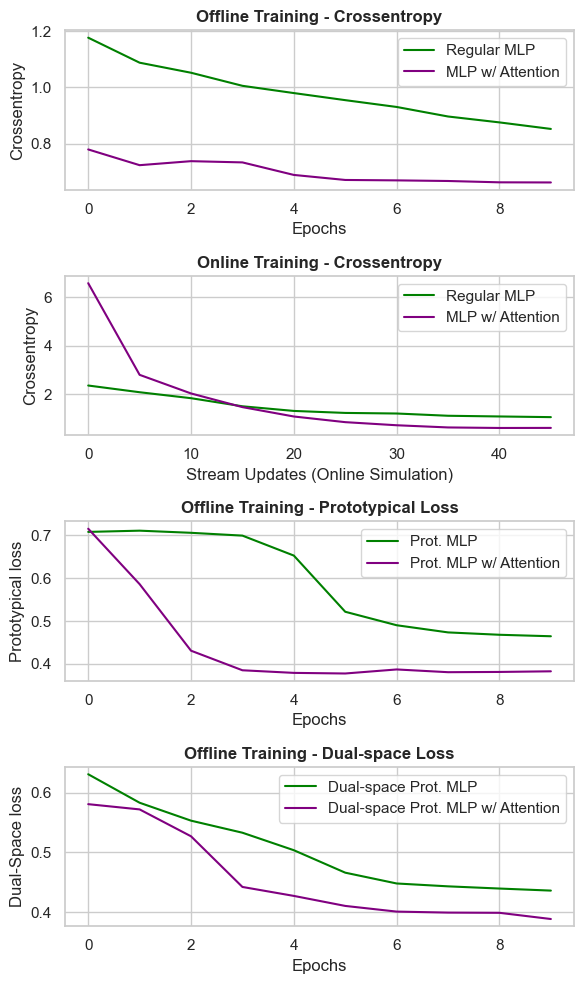

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a figure and a set of subplots
sns.set(style="whitegrid") 
fig, axs = plt.subplots(4, 1, figsize=(6, 10))

# Plotting for Offline Training
sns.lineplot(x='epochs', y=history_mlp_offline["val_loss"], data=history_mlp_offline, ax=axs[0], color='green', label='Regular MLP')
sns.lineplot(x='epochs', y=history_att_offline["val_loss"], data=history_att_offline, ax=axs[0], color='purple', label='MLP w/ Attention')
axs[0].set_title('Offline Training - Crossentropy', weight='bold')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Crossentropy')

# Plotting for Online Training
sns.lineplot(x='updates', y=history_mlp_online["val_loss"], data=history_mlp_online, ax=axs[1], color='green', label='Regular MLP')
sns.lineplot(x='updates', y=history_att_online["val_loss"], data=history_att_online, ax=axs[1], color='purple', label='MLP w/ Attention')
axs[1].set_title('Online Training - Crossentropy', weight='bold')
axs[1].set_xlabel('Stream Updates (Online Simulation)')
axs[1].set_ylabel('Crossentropy')

# Plotting for Prototypical Training
sns.lineplot(x='epochs', y=[float(val) for val in history_mlp_prototypical["val_loss"]], data=history_mlp_prototypical, ax=axs[2], color='green', label='Prot. MLP')
sns.lineplot(x='epochs', y=[float(val) for val in history_att_prototypical["val_loss"]], data=history_att_prototypical, ax=axs[2], color='purple', label='Prot. MLP w/ Attention')
axs[2].set_title('Offline Training - Prototypical Loss', weight='bold')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel('Prototypical loss')
plt.tight_layout()

# Plotting for Prototypical Training
sns.lineplot(x='epochs', y=[float(val) for val in history_mlp_ds_loss["val_loss"]], data=history_mlp_ds_loss, ax=axs[3], color='green', label='Dual-space Prot. MLP')
sns.lineplot(x='epochs', y=[0.5806478261947632,
 0.5718628764152527,
 0.5268269181251526,
 0.44199731945991516,
 0.4270021617412567,
 0.4102267324924469,
 0.40071943759918213,
 0.3990399885177612,
 0.3986844027042389,
 0.3883061909675598], data=history_att_ds_loss, ax=axs[3], color='purple', label='Dual-space Prot. MLP w/ Attention')
axs[3].set_title('Offline Training - Dual-space Loss', weight='bold')
axs[3].set_xlabel('Epochs')
axs[3].set_ylabel('Dual-Space loss')
plt.tight_layout()

In [80]:
[float(val) for val in history_att_ds_loss["val_loss"]]

[0.5806478261947632,
 0.5718628764152527,
 0.5268269181251526,
 0.44199731945991516,
 0.4270021617412567,
 0.4102267324924469,
 0.49071943759918213,
 0.5190399885177612,
 0.4086844027042389,
 0.3983061909675598]

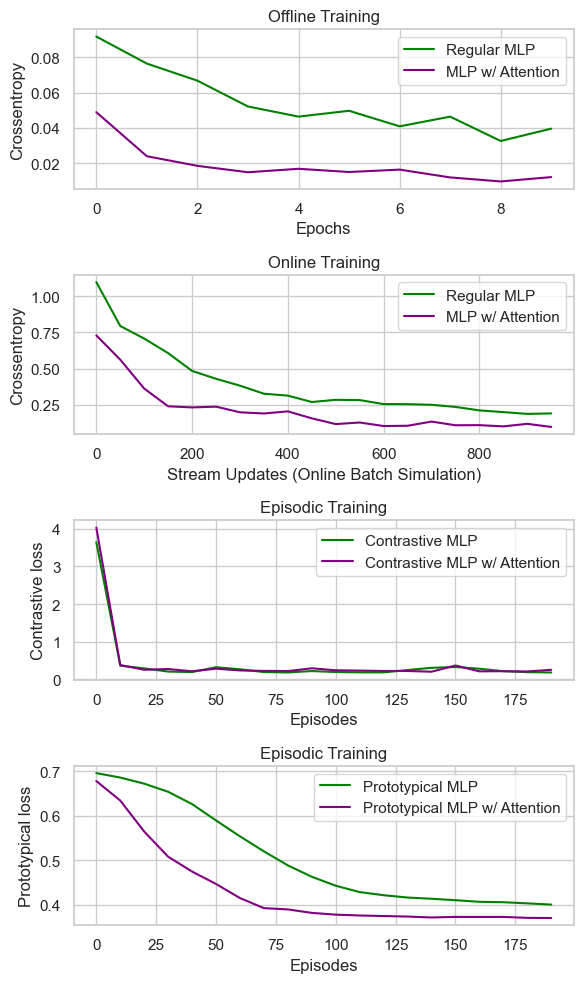

In [217]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# # Create a figure and a set of subplots
# sns.set(style="whitegrid") 
# fig, axs = plt.subplots(4, 1, figsize=(6, 10))

# # Plotting for Offline Training
# sns.lineplot(x='epochs', y=history_mlp_offline["val_loss"], data=history_mlp_offline, ax=axs[0], color='green', label='Regular MLP')
# sns.lineplot(x='epochs', y=history_att_offline["val_loss"], data=history_att_offline, ax=axs[0], color='purple', label='MLP w/ Attention')
# axs[0].set_title('Offline Training')
# axs[0].set_xlabel('Epochs')
# axs[0].set_ylabel('Crossentropy')

# # Plotting for Online Training
# sns.lineplot(x='updates', y=history_mlp_online["val_loss"], data=history_mlp_online, ax=axs[1], color='green', label='Regular MLP')
# sns.lineplot(x='updates', y=history_att_online["val_loss"], data=history_att_online, ax=axs[1], color='purple', label='MLP w/ Attention')
# axs[1].set_title('Online Training')
# axs[1].set_xlabel('Stream Updates (Online Batch Simulation)')
# axs[1].set_ylabel('Crossentropy')

# # Plotting for Prototypical Training
# sns.lineplot(x='episodes', y=[3.641626739501953,
#   0.3668282926082611,
#   0.29396459460258484,
#   0.2098522186279297,
#   0.19639179110527039,
#   0.3251732289791107,
#   0.2699073255062103,
#   0.19637708365917206,
#   0.18645700812339783,
#   0.22363248467445374,
#   0.1976422369480133,
#   0.18849308788776398,
#   0.18868349492549896,
#   0.25085848569869995,
#   0.30910176038742065,
#   0.33119145035743713,
#   0.285185843706131,
#   0.21921248733997345,
#   0.1945280134677887,
#   0.18557044863700867], data=history_mlp_contrastive, ax=axs[2], color='green', label='Contrastive MLP')
# sns.lineplot(x='episodes', y=[4.02578735351562,  0.38218337297439575,  0.2581483721733093,  0.2769737243652344,  0.2179214060306549,
#   0.2864390015602112,
#   0.23987898230552673,
#   0.22788488864898682,
#   0.22217659652233124,
#   0.2971992492675781,
#   0.24391663074493408,
#   0.23539629578590393,
#   0.2255435287952423,
#   0.224997878074646,
#   0.2059243619441986,
#   0.37081900238990784,
#   0.2152014523744583,
#   0.22031638026237488,
#   0.21238958835601807,
#   0.25659555196762085], data=history_att_contrastive, ax=axs[2], color='purple', label='Contrastive MLP w/ Attention')
# axs[2].set_title('Episodic Training')
# axs[2].set_xlabel('Episodes')
# axs[2].set_ylabel('Contrastive loss')

# # Plotting for Prototypical Training
# sns.lineplot(x='episodes', y=[float(val) for val in history_mlp_prototypical["val_loss"]], data=history_mlp_prototypical, ax=axs[3], color='green', label='Prototypical MLP')
# sns.lineplot(x='episodes', y=[float(val) for val in history_att_prototypical["val_loss"]], data=history_att_prototypical, ax=axs[3], color='purple', label='Prototypical MLP w/ Attention')
# axs[3].set_title('Episodic Training')
# axs[3].set_xlabel('Episodes')
# axs[3].set_ylabel('Prototypical loss')
# plt.tight_layout()

In [20]:
# offline_results = {"MLP":[], "Att":[]}
# online_results = {"MLP":[], "Att":[]}
prot_results = {"MLP":[], "Att":[]}

for i in range(5):
    num_epochs = 10  
    # samples_training = torch.randperm(X_train.shape[0])[:100]

    # train_dataset = TensorDataset(X_train[samples_training,:], y_train[samples_training])
    # train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    # -> OFFLINE
    ## MLP
    # MLP_offline = MLP_Binary(len(features_RFC))
    # criterion = nn.BCELoss()
    # optimizer = torch.optim.Adam(MLP_offline.parameters(), lr=0.001, weight_decay=0.01)
    # offline_learning(MLP_offline, criterion, optimizer, train_dataloader, val_dataloader, num_epochs, early_stopper)


    # Att_offline = Binary_Att(len(features_RFC))
    # criterion = nn.BCELoss() 
    # optimizer = torch.optim.Adam(Att_offline.parameters(), lr=0.001, weight_decay=0.01)

    # offline_learning(Att_offline, criterion, optimizer, train_dataloader, val_dataloader, num_epochs, early_stopper)

    # # Results with test data
    # X_test_data_scaled = scaler.transform(X_test_data[features_RFC].values)
    # offline_results["MLP"].append(evaluate_model(MLP_offline, X_test_data_scaled, y_test_data.values))
    # offline_results["Att"].append(evaluate_model(Att_offline, X_test_data_scaled, y_test_data.values))

    # -> ONLINE
    # MLP_online = MLP_Binary(len(features_RFC))
    # criterion = nn.BCELoss()
    # optimizer = torch.optim.AdamW(MLP_online.parameters(), lr=0.001) # implement Adam w/ decoupling weight decay L_2

    # # Preprocess
    # X_train_data_scaled = scaler.fit_transform(X_train_data[features_RFC].values)
    # y_train_data_values = y_train_data.values.astype(np.float32)

    # # Initialize the data stream
    # data_stream = data_stream_generator(X_train_data_scaled, y_train_data_values, batch_size=32)

    # # Running online learning
    # num_updates = 1000  # Set this to the desired number of updates
    # online_learning(MLP_online, criterion, optimizer, data_stream, val_dataloader, num_updates)

    # Att_online = Binary_Att(len(features_RFC))
    # criterion = nn.BCELoss()
    # optimizer = torch.optim.AdamW(Att_online.parameters(), lr=0.001) # implement Adam w/ decoupling weight decay L_2

    # # Running online learning
    # num_updates = 1000  # Set to the desired number of updates
    # online_learning(Att_online, criterion, optimizer, data_stream, val_dataloader, num_updates)

    # # Results with test data
    # online_results["MLP"].append(evaluate_model(MLP_online, X_test_data_scaled, y_test_data.values))
    # online_results["Att"].append(evaluate_model(Att_online, X_test_data_scaled, y_test_data.values))

    # -> Prototypical
    Prototypical_MLP = MLP_Binary(len(features_RFC))
    optimizer = torch.optim.Adam(Prototypical_MLP.parameters(), lr=0.001, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()  # or another suitable loss function

    n_episodes = 200  
    n_support = 100  
    n_query = 100     
    episodes, unique_indices = create_episodes(X_train, y_train, n_episodes, n_support, n_query)#create_episodes(X_train[samples_training,:], y_train[samples_training], n_episodes, n_support, n_query)

    print(f"Total unique inputs used for training: {len(unique_indices)}")
    
    episodic_training(Prototypical_MLP, optimizer, num_epochs, episodes, val_dataloader)
    
    Prototypical_Att = Binary_Att(len(features_RFC))
    optimizer = torch.optim.Adam(Prototypical_Att.parameters(), lr=0.001, weight_decay=0.01)
    # episodes, unique_indices = create_episodes(X_train, y_train, n_episodes, n_support, n_query)
    episodic_training(Prototypical_Att, optimizer, num_epochs, episodes, val_dataloader)

    ############################ TEST ############################
    X_test_data_scaled = scaler.transform(X_test_data[features_RFC].values)
    X_test, y_test = torch.tensor(X_test_data_scaled, dtype=torch.float32), torch.tensor(y_test_data.values, dtype=torch.float32)
    test_dataset = TensorDataset(X_test, y_test)
    test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    prot_results["MLP"].append(validate_with_prototypes_test(Prototypical_MLP, test_dataloader))
    prot_results["Att"].append(validate_with_prototypes_test(Prototypical_Att, test_dataloader))

Total unique inputs used for training: 73198
New best loss: 0.4633517563343048 at epoch 0. Model saved.
Epoch 0, Training Loss: 0.6605559374392033, Val Loss: 0.4633517563343048, Val Accuracy: 0.8625040851156541
New best loss: 0.3711414933204651 at epoch 1. Model saved.
Epoch 1, Training Loss: 0.4043761676549911, Val Loss: 0.3711414933204651, Val Accuracy: 0.9559397581611533
New best loss: 0.3627985119819641 at epoch 2. Model saved.
Epoch 2, Training Loss: 0.3661861573159695, Val Loss: 0.3627985119819641, Val Accuracy: 0.9602472856675986
Epoch 3: loss did not improve from 0.3627985119819641.
Epoch 3, Training Loss: 0.3635178895294666, Val Loss: 0.3634452521800995, Val Accuracy: 0.9604197683285522
New best loss: 0.36213982105255127 at epoch 4. Model saved.
Epoch 4, Training Loss: 0.363033032566309, Val Loss: 0.36213982105255127, Val Accuracy: 0.9605786339373252
Epoch 5: loss did not improve from 0.36213982105255127.
Epoch 5, Training Loss: 0.36349385246634486, Val Loss: 0.363320529460907

In [297]:
pd.DataFrame(prot_results["Att"]).std()

accuracy     0.003697
precision    0.000767
recall       0.007968
f1_score     0.003944
dtype: float64

In [244]:
# N training = 100; N test: 220312
pd.DataFrame(offline_results["MLP"]).std()

accuracy     0.060197
precision    0.153404
recall       0.272680
f1_score     0.116953
dtype: float64

In [246]:
# N= 100
pd.DataFrame(offline_results["Att"]).std()

accuracy     0.118475
precision    0.191799
recall       0.230925
f1_score     0.117806
dtype: float64

In [270]:
pd.DataFrame(prot_results["Att"]).mean()

accuracy     0.944466
precision    0.974350
recall       0.913267
f1_score     0.942600
dtype: float64

In [265]:
# N= 100
pd.DataFrame(prot_results["MLP"]).mean()

accuracy     0.962356
precision    0.989174
recall       0.934974
f1_score     0.961287
dtype: float64

In [266]:
pd.DataFrame(prot_results["Att"]).mean()

accuracy     0.969664
precision    0.993127
recall       0.945877
f1_score     0.968911
dtype: float64

In [212]:
pd.DataFrame(offline_results["Att"]).mean()

accuracy     0.850620
precision    0.914386
recall       0.808930
f1_score     0.835021
dtype: float64

In [39]:
pd.DataFrame(offline_results["Att"]).std()

accuracy     0.003430
precision    0.008286
recall       0.009930
f1_score     0.003470
dtype: float64

## Prototypical with loss based on Cosine 

In [225]:
class MLP_Binary(nn.Module):
    def __init__(self, n_features):
        super(MLP_Binary, self).__init__()
        self.input_layer = nn.Linear(n_features, 32)
        self.hidden_layer = nn.Linear(32, 16)
        self.output_layer = nn.Linear(16, 1)

    def forward(self, model_input, return_embedding=False):
        x = F.relu(self.input_layer(model_input))
        x = F.dropout(x)
        embedding = F.relu(self.hidden_layer(x))
        if return_embedding:
            return embedding
        x = torch.sigmoid(self.output_layer(embedding))
        return x

class Binary_Att(nn.Module):
    def __init__(self, n_features):
        super(Binary_Att, self).__init__()
        self.input_layer = nn.Linear(n_features, 32)
        self.attention = Attention(32, n_features)
        self.after_attn = nn.Linear(32, 16)
        self.output_layer = nn.Linear(16, 1)

    def forward(self, model_input, return_embedding=False):
        x = F.relu(self.input_layer(model_input))
        x, att_weights = self.attention(x)
        embedding = F.relu(self.after_attn(x))
        if return_embedding:
            return embedding
        x = torch.sigmoid(self.output_layer(embedding))
        return x

def create_episodes(X, y, n_episodes, n_support, n_query):
    episodes = []
    class_indices = {0: [], 1: []}
    all_indices = set()  # Track all used indices

    # Separate indices for each class
    for idx, label in enumerate(y):
        class_indices[label.item()].append(idx)

    for _ in range(n_episodes):
        support_indices = []
        query_indices = []

        for class_label in [0, 1]:
            selected_indices = random.sample(class_indices[class_label], n_support + n_query)
            all_indices.update(selected_indices)  # Update the set with new indices
            support_indices.extend(selected_indices[:n_support])
            query_indices.extend(selected_indices[n_support:])

        support_set = (X[support_indices], y[support_indices])
        query_set = (X[query_indices], y[query_indices])
        episodes.append((support_set, query_set))

    return episodes, all_indices

def compute_prototypes(embeddings, labels):
    """
    Compute class prototypes from embeddings
    """
    classes = torch.unique(labels)
    prototypes = torch.stack([embeddings[labels == c].mean(0) for c in classes])
    return prototypes

def cosine_similarity(x1, x2):
    # Normalize input vectors to compute cosine similarity
    x1_norm = F.normalize(x1, p=2, dim=1)
    x2_norm = F.normalize(x2, p=2, dim=1)
    return torch.mm(x1_norm, x2_norm.transpose(0, 1))

def hybrid_prototype_loss(query_embeddings, prototypes, query_labels, alpha=0.7):
    """
    Calculate the Prototype Loss.
    """
    # Compute distances and apply softmax
    euclidean_distances = F.normalize(torch.cdist(query_embeddings, prototypes), p=2, dim=1)
    cosine_distances = 1 - cosine_similarity(query_embeddings, prototypes)
    combined_distances = (alpha * euclidean_distances) + ((1 - alpha) * cosine_distances)
    predictions = F.log_softmax(-combined_distances, dim=1)
    # Cross-entropy loss expects class indices
    criterion = nn.CrossEntropyLoss()
    return criterion(predictions, query_labels.long())

# Prototypes
def validate_with_prototypes(model, dataloader):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            emb = model(inputs, return_embedding=True)
            embeddings.append(emb)
            labels.append(targets)

    embeddings = torch.cat(embeddings)
    labels = torch.cat(labels)

    # Compute prototypes
    prototypes = compute_prototypes(embeddings, labels)

    # Classify based on nearest prototype
    distances = torch.cdist(embeddings, prototypes)
    predictions = torch.argmin(distances, dim=1)
    val_loss = hybrid_prototype_loss(embeddings, prototypes, labels)
    accuracy = accuracy_score(labels.numpy(), predictions.numpy())
    return accuracy, val_loss

def episodic_training(model, optimizer, epochs, episodes, val_dataloader):
    history = {}
    history["epochs"], history["loss"], history["val_loss"] = [], [], []
    for epoch in range(epochs):
        total_loss = 0
        for episode_index, episode in enumerate(episodes):
            model.train()
            

            # Extract support and query sets
            support_set, query_set = episode
            support_embeddings = model(support_set[0], return_embedding=True)
            query_embeddings = model(query_set[0], return_embedding=True)

            # Compute prototypes
            prototypes = compute_prototypes(support_embeddings, support_set[1])

            # Calculate loss using the prototype loss function
            loss = hybrid_prototype_loss(query_embeddings, prototypes, query_set[1])

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()


        val_accuracy, val_loss = validate_with_prototypes(model, val_dataloader)
        print(f"Epoch {epoch}, Training Loss: {total_loss / len(episodes)}, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}")
        history["epochs"].append(epoch)
        history["loss"].append(total_loss / len(episodes))
        history["val_loss"].append(val_loss)
    return history

# Define your model
Prototypical_MLP = MLP_Binary(len(features_RFC))  # or Binary_Att(n_features)

# Define the optimizer and loss function
optimizer = torch.optim.Adam(Prototypical_MLP.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()  # or another suitable loss function

n_episodes = 99  # for example
n_support = 20   # number of support samples per class
n_query = 20     # number of query samples per class

samples_training = torch.randperm(X_train.shape[0])[:100]

episodes, unique_indices = create_episodes(X_train[samples_training,:], y_train[samples_training], n_episodes, n_support, n_query)

print(f"Total unique inputs used for training: {len(unique_indices)}")
history_mlp_prototypical = episodic_training(Prototypical_MLP, optimizer,10, episodes, val_dataloader)

Total unique inputs used for training: 100
Epoch 0, Training Loss: 0.6517264463684775, Val Loss: 0.6158427596092224, Val Accuracy: 0.5793692581429972
Epoch 1, Training Loss: 0.5404892226662299, Val Loss: 0.5029007792472839, Val Accuracy: 0.8395638912088311
Epoch 2, Training Loss: 0.4683742616513763, Val Loss: 0.4618377387523651, Val Accuracy: 0.8720314826246414
Epoch 3, Training Loss: 0.4271957522088831, Val Loss: 0.44135957956314087, Val Accuracy: 0.9128962562184538
Epoch 4, Training Loss: 0.40629934421693437, Val Loss: 0.43030253052711487, Val Accuracy: 0.9301218272268419
Epoch 5, Training Loss: 0.3969661701809276, Val Loss: 0.43378594517707825, Val Accuracy: 0.9330358763934783
Epoch 6, Training Loss: 0.3889103143504172, Val Loss: 0.4219680726528168, Val Accuracy: 0.9439612912596681
Epoch 7, Training Loss: 0.3813379102885121, Val Loss: 0.41190505027770996, Val Accuracy: 0.9468980355132721
Epoch 8, Training Loss: 0.3744447439005881, Val Loss: 0.3981472849845886, Val Accuracy: 0.952335

In [206]:
# Define your model
Prototypical_Att = Binary_Att(len(features_RFC))  # or Binary_Att(n_features)

# Define the optimizer and loss function
optimizer = torch.optim.Adam(Prototypical_Att.parameters(), lr=0.001, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()  # or another suitable loss function

n_episodes = 99  # for example
n_support = 20   # number of support samples per class
n_query = 20     # number of query samples per class

samples_training = torch.randperm(X_train.shape[0])[:100]

episodes, unique_indices = create_episodes(X_train[samples_training,:], y_train[samples_training], n_episodes, n_support, n_query)
print(f"Total unique inputs used for training: {len(unique_indices)}")
history_att_prototypical = episodic_training(Prototypical_Att, optimizer, 10,episodes, val_dataloader)

Total unique inputs used for training: 100
Epoch 0, Training Loss: 0.6223671625960957, Val Loss: 0.31698983907699585, Val Accuracy: 0.9313882130796325
Epoch 1, Training Loss: 0.41804229520788094, Val Loss: 0.3837912678718567, Val Accuracy: 0.9553406078652094
Epoch 2, Training Loss: 0.39263163792966593, Val Loss: 0.44678035378456116, Val Accuracy: 0.95243563673336
Epoch 3, Training Loss: 0.40989808392043064, Val Loss: 0.49544087052345276, Val Accuracy: 0.9475743491049058
Epoch 4, Training Loss: 0.42243466232762195, Val Loss: 0.5651909112930298, Val Accuracy: 0.9411289444061149
Epoch 5, Training Loss: 0.40901091724935207, Val Loss: 0.5393655896186829, Val Accuracy: 0.9443380297033298
Epoch 6, Training Loss: 0.4427518769346102, Val Loss: 0.5046076774597168, Val Accuracy: 0.9172764080031954
Epoch 7, Training Loss: 0.42535650338789427, Val Loss: 0.47679877281188965, Val Accuracy: 0.9498393187842695
Epoch 8, Training Loss: 0.41020879992330916, Val Loss: 0.470533162355423, Val Accuracy: 0.947

In [300]:
# Embedding plots

In [21]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def extract_embeddings_plot(model, dataloader):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            emb = model(inputs, return_embedding=True)
            embeddings.append(emb)
            labels.append(targets)

    embeddings = torch.cat(embeddings).numpy()
    labels = torch.cat(labels).numpy()
    return embeddings, labels



embeddings, labels = extract_embeddings_plot(Prototypical_MLP, val_dataloader)  # Assuming validation_dataloader is defined
# tsne = TSNE(n_components=2, random_state=42)
# embeddings_2d = tsne.fit_transform(embeddings)

# for label in np.unique(labels):
#     indices = np.where(labels == label)
#     plt.scatter(embeddings_2d[indices, 0], embeddings_2d[indices, 1], label=label, alpha=0.5)
# plt.legend()
# plt.title('2D projection of embeddings')
# plt.xlabel('Component 1')
# plt.ylabel('Component 2')
# plt.show()

/Users/femartinez/anaconda3/envs/dos_project/lib/python3.11/site-packages/umap/spectral.py:260: UserWarning: WARNING: spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/femartinez/anaconda3/envs/dos_project/lib/python3.11/site-packages/umap/spectral.py:260: UserWarning: WARNING: spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


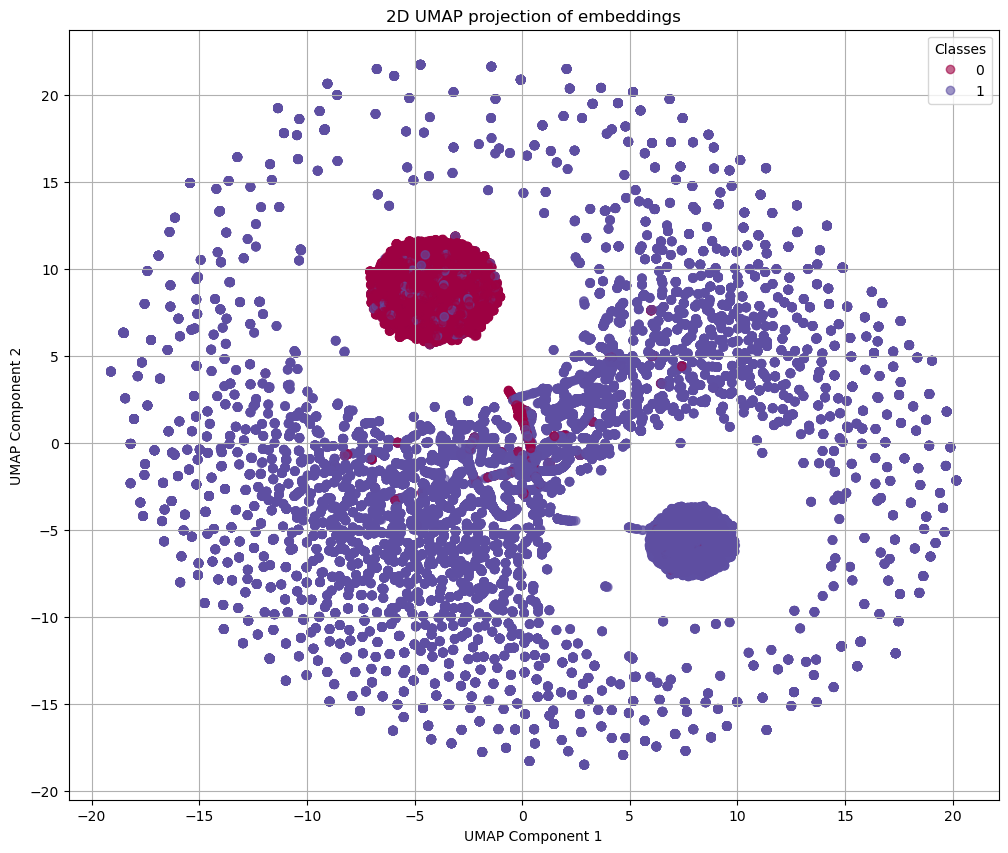

In [24]:
from sklearn.preprocessing import StandardScaler
from umap import UMAP
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

# Apply UMAP
umap = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embeddings_2d = umap.fit_transform(embeddings_scaled)

# Plot the 2D embeddings
plt.figure(figsize=(12, 10))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='Spectral', alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('2D UMAP projection of embeddings')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.show()